In [1]:
import sqlite3
import pandas as pd
import numpy as np

db_path = "../database/online_retail.db"  # local
conn = sqlite3.connect(db_path)

# Ver qué tablas existen
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,transactions
1,transactions_clean


In [2]:
query = """
SELECT
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country
FROM transactions_clean
WHERE CustomerID IS NOT NULL
  AND Quantity > 0
  AND UnitPrice > 0
  AND InvoiceNo NOT LIKE 'C%';
"""
df_tx = pd.read_sql(query, conn)
df_tx.shape

(397884, 8)

In [3]:
query_rfm = """
WITH base AS (
    SELECT
        CustomerID,
        InvoiceNo,
        DATE(InvoiceDate) AS invoice_day,
        Quantity * UnitPrice AS line_revenue
    FROM transactions_clean
    WHERE CustomerID IS NOT NULL
      AND Quantity > 0
      AND UnitPrice > 0
      AND InvoiceNo NOT LIKE 'C%'
),
ref AS (
    SELECT DATE(MAX(invoice_day), '+1 day') AS ref_date
    FROM base
),
rfm AS (
    SELECT
        CustomerID,
        CAST((julianday((SELECT ref_date FROM ref)) - julianday(MAX(invoice_day))) AS INTEGER) AS recency_days,
        COUNT(DISTINCT InvoiceNo) AS frequency_orders,
        ROUND(SUM(line_revenue), 2) AS monetary_revenue
    FROM base
    GROUP BY CustomerID
)
SELECT *
FROM rfm;
"""
df_rfm = pd.read_sql(query_rfm, conn)
df_rfm.head(), df_rfm.shape

(   CustomerID  recency_days  frequency_orders  monetary_revenue
 0     12346.0           326                 1          77183.60
 1     12347.0             3                 7           4310.00
 2     12348.0            76                 4           1797.24
 3     12349.0            19                 1           1757.55
 4     12350.0           311                 1            334.40,
 (4338, 4))

In [4]:
df_rfm.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])

,CustomerID,recency_days,frequency_orders,monetary_revenue
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,93.059474,4.272015,2054.266459
std,1721.808492,100.012264,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
1%,12401.370000,2.000000,1.000000,52.200000
5%,12614.850000,3.000000,1.000000,112.309500
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.750000,5.000000,1661.740000
95%,17984.150000,312.000000,13.000000,5841.843000


In [5]:
df_rfm["frequency_orders_c"] = df_rfm["frequency_orders"].clip(upper=df_rfm["frequency_orders"].quantile(0.99))
df_rfm["monetary_revenue_c"] = df_rfm["monetary_revenue"].clip(upper=df_rfm["monetary_revenue"].quantile(0.99))
df_rfm["recency_days_c"] = df_rfm["recency_days"].clip(upper=df_rfm["recency_days"].quantile(0.99))

In [6]:
# Recency invertido: menos días => score más alto
df_rfm["R"] = pd.qcut(df_rfm["recency_days_c"], 5, labels=[5,4,3,2,1]).astype(int)

df_rfm["F"] = pd.qcut(df_rfm["frequency_orders_c"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
df_rfm["M"] = pd.qcut(df_rfm["monetary_revenue_c"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

df_rfm["RFM"] = df_rfm["R"].astype(str) + df_rfm["F"].astype(str) + df_rfm["M"].astype(str)
df_rfm.head()

,CustomerID,recency_days,frequency_orders,monetary_revenue,frequency_orders_c,monetary_revenue_c,recency_days_c,R,F,M,RFM
0,12346.0,326,1,77183.60,1,19880.9957,326.0,1,1,5,115
1,12347.0,3,7,4310.00,7,4310.0000,3.0,5,5,5,555
2,12348.0,76,4,1797.24,4,1797.2400,76.0,2,4,4,244
3,12349.0,19,1,1757.55,1,1757.5500,19.0,4,1,4,414
4,12350.0,311,1,334.40,1,334.4000,311.0,1,1,2,112


In [7]:
def segment(row):
    R, F, M = row["R"], row["F"], row["M"]

    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"
    if R >= 4 and F >= 3 and M >= 3:
        return "Loyal Customers"
    if R == 5 and F <= 2:
        return "New Customers"
    if R <= 2 and F >= 4:
        return "At Risk (High Frequency)"
    if R <= 2 and M >= 4:
        return "At Risk (High Value)"
    if R <= 2 and F <= 2 and M <= 2:
        return "Hibernating"
    if R == 3 and F <= 2:
        return "Potential Loyalists"
    return "Others"

df_rfm["segment"] = df_rfm.apply(segment, axis=1)

df_rfm["segment"].value_counts().to_frame("customers")

,customers
segment,
Others,1322
Champions,953
Hibernating,827
Potential Loyalists,352
Loyal Customers,333
At Risk (High Frequency),283
At Risk (High Value),169
New Customers,99


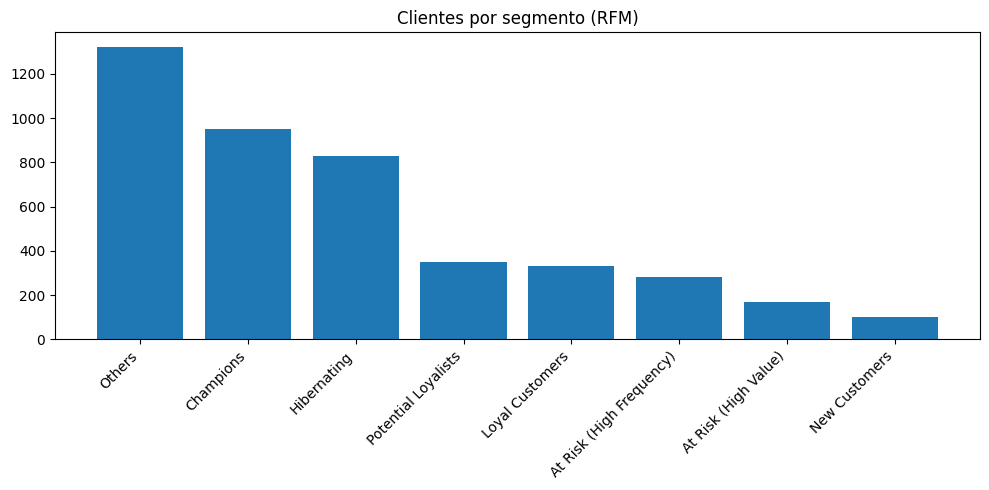

In [8]:
import matplotlib.pyplot as plt

seg_counts = df_rfm["segment"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(seg_counts.index, seg_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Clientes por segmento (RFM)")
plt.tight_layout()
plt.show()

In [9]:
seg_summary = (
    df_rfm.groupby("segment")
    .agg(
        customers=("CustomerID","count"),
        avg_recency=("recency_days","mean"),
        avg_frequency=("frequency_orders","mean"),
        avg_monetary=("monetary_revenue","mean"),
        total_revenue=("monetary_revenue","sum"),
    )
    .sort_values("total_revenue", ascending=False)
)

seg_summary

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
segment,,,,,
Champions,953,13.167891,11.123820,6054.820094,5770243.55
Others,1322,84.125567,2.836611,1018.206982,1346069.63
Loyal Customers,333,16.777778,3.198198,1438.079580,478880.50
At Risk (High Value),169,162.449704,1.982249,2720.675030,459794.08
At Risk (High Frequency),283,135.773852,4.872792,1589.843675,449925.76
Hibernating,827,228.467956,1.042322,230.419178,190556.66
Potential Loyalists,352,53.312500,1.161932,471.994375,166142.02
New Customers,99,7.626263,1.323232,502.986869,49795.70


In [10]:
import os
os.makedirs("../data/processed", exist_ok=True)

df_rfm.to_csv("../data/processed/rfm_customers.csv", index=False)
seg_summary.to_csv("../data/processed/rfm_segment_summary.csv")

El dataset cubre del min_date al max_date.

RFM permite priorizar retención/activación: Champions vs At Risk vs Hibernating.

Acciones sugeridas:

Champions: beneficios VIP / early access

At Risk (High Value): campaña de winback con incentivo

New Customers: onboarding (segunda compra)

Hibernating: campañas de bajo costo / limpieza de base